In [2]:
!pip install torch

In [4]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 5.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.8/241.8 kB 6.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.1/256.1 kB 6.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.4/224.4 kB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.6/355.6 kB 7.3 MB/s eta 0:00:00a 0:00:01


In [5]:
#Loading dataset and mapping attributes into binary

import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split

# Load your cleaned dataset
df = pd.read_csv("SelectedClean_nhis2023.csv")

# --- Apply binary mappings ---
df['ANXEV_A'] = df['ANXEV_A'].map({'Yes': 1, 'No': 0}).astype(int)

df['SEX_A'] = df['SEX_A'].map({'Male': 0, 'Female': 1}).astype(int)

df['HISPALLP_BIN'] = df['HISPALLP_A'].map({
    'Non-Hispanic White only': 1,  
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}).astype(int)

# --- Define features, target, and protected attribute ---
X = df.drop(columns=["SEX_A", "HISPALLP_A", "HISPALLP_BIN"]).values
y = df["HISPALLP_BIN"].values        # Target: White vs Non-White (binary)
prot_attr = df["SEX_A"].values       # Protected attribute: Male(0)/Female(1)

# --- Build kNN graph ---
knn_graph = kneighbors_graph(X, n_neighbors=10, mode='connectivity', include_self=False)
edge_index = torch.tensor(np.array(knn_graph.nonzero()), dtype=torch.long)

# Convert to tensors
x = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.long)
prot_attr = torch.tensor(prot_attr, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

# Train/test split
train_idx, test_idx = train_test_split(range(data.num_nodes), test_size=0.2, random_state=42)
train_idx, test_idx = torch.tensor(train_idx), torch.tensor(test_idx)



In [6]:
#Define GCN model

import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


In [7]:
#Training + Evaluation Functions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(edge_index, epochs=100, hidden_dim=32):
    model = GCN(input_dim=x.shape[1], hidden_dim=hidden_dim, output_dim=len(y.unique())).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(x.to(device), edge_index.to(device))
        loss = F.cross_entropy(out[train_idx], y[train_idx].to(device))
        loss.backward()
        optimizer.step()
    return model

def evaluate_model(model, edge_index):
    model.eval()
    out = model(x.to(device), edge_index.to(device))
    pred = out.argmax(dim=1).cpu()
    acc = (pred[test_idx] == y[test_idx]).sum().item() / len(test_idx)
    return pred.numpy(), acc


In [11]:
# General Fairness Evaluation for Models

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

def evaluate_fairness(y_true, y_pred, prot_attr, prot_name="SEX_A"):
    # Build a single DataFrame with true + predicted labels
    df_eval = pd.DataFrame({
        "true_label": y_true,
        "pred_label": y_pred,
        prot_name: prot_attr
    })

    # Dataset with true labels
    dataset_true = BinaryLabelDataset(
        df=df_eval[["true_label", prot_name]].astype(int).rename(columns={"true_label": "label"}),
        label_names=["label"],
        protected_attribute_names=[prot_name]
    )

    # Dataset with predicted labels (identical except label column swapped)
    dataset_pred = BinaryLabelDataset(
        df=df_eval[["pred_label", prot_name]].astype(int).rename(columns={"pred_label": "label"}),
        label_names=["label"],
        protected_attribute_names=[prot_name]
    )

    # Now AIF360 sees both datasets as identical except labels
    metric = ClassificationMetric(
        dataset_true, dataset_pred,
        privileged_groups=[{prot_name: 1}],
        unprivileged_groups=[{prot_name: 0}]
    )

    return {
        "Mean Difference": metric.mean_difference(),
        "Disparate Impact": metric.disparate_impact(),
        "Statistical Parity Diff": metric.statistical_parity_difference()
    }





In [12]:
# Baseline GCN without FairDrop

model_base = train_model(data.edge_index, epochs=200)
pred_base, acc_base = evaluate_model(model_base, data.edge_index)

fairness_base = evaluate_fairness(y.numpy(), pred_base, prot_attr.numpy(), prot_name="SEX_A")

print("\n=== Baseline GCN ===")
print("Accuracy:", acc_base)
print("Fairness:", fairness_base)




=== Baseline GCN ===
Accuracy: 0.6576714188730483
Fairness: {'Mean Difference': np.float64(-0.003042154096685512), 'Disparate Impact': np.float64(0.9969118110274687), 'Statistical Parity Diff': np.float64(-0.003042154096685512)}


In [13]:
# GCN with FairDrop

from torch_geometric.utils import dropout_edge

def fairdrop_edge_index(edge_index, drop_rate=0.2):
    edge_index, _ = dropout_edge(edge_index, p=drop_rate)
    return edge_index

edge_index_fair = fairdrop_edge_index(data.edge_index, drop_rate=0.2)

model_fair = train_model(edge_index_fair, epochs=200)
pred_fair, acc_fair = evaluate_model(model_fair, edge_index_fair)

fairness_fair = evaluate_fairness(y.numpy(), pred_fair, prot_attr.numpy(), prot_name="SEX_A")

print("\n=== GCN + FairDrop ===")
print("Accuracy:", acc_fair)
print("Fairness:", fairness_fair)



=== GCN + FairDrop ===
Accuracy: 0.6588594704684317
Fairness: {'Mean Difference': np.float64(-0.0011594745998736444), 'Disparate Impact': np.float64(0.9988299435888863), 'Statistical Parity Diff': np.float64(-0.0011594745998736444)}


In [14]:
# Fairness Evaluation with multiple protected attributes

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

def evaluate_fairness_multi(y_true, y_pred, df, prot_cols):
    results = []

    for prot_name in prot_cols:
        prot_attr = df[prot_name].values

        # Build DataFrame with true + predicted labels
        df_eval = pd.DataFrame({
            "true_label": y_true,
            "pred_label": y_pred,
            prot_name: prot_attr
        })

        # Dataset with true labels
        dataset_true = BinaryLabelDataset(
            df=df_eval[["true_label", prot_name]].astype(int).rename(columns={"true_label": "label"}),
            label_names=["label"],
            protected_attribute_names=[prot_name]
        )

        # Dataset with predicted labels (same structure, label replaced)
        dataset_pred = BinaryLabelDataset(
            df=df_eval[["pred_label", prot_name]].astype(int).rename(columns={"pred_label": "label"}),
            label_names=["label"],
            protected_attribute_names=[prot_name]
        )

        # Fairness metrics
        metric = ClassificationMetric(
            dataset_true, dataset_pred,
            privileged_groups=[{prot_name: 1}],
            unprivileged_groups=[{prot_name: 0}]
        )

        results.append({
            "Protected Attribute": prot_name,
            "Mean Difference": metric.mean_difference(),
            "Disparate Impact": metric.disparate_impact(),
            "Statistical Parity Diff": metric.statistical_parity_difference()
        })
    
    return pd.DataFrame(results)


In [16]:
#Fairness metrics for Protected Attributes

prot_cols = ["SEX_A", "HISPALLP_BIN"]

# Baseline GCN fairness
fairness_base = evaluate_fairness_multi(y.numpy(), pred_base, df, prot_cols)

# FairDrop fairness
fairness_fair = evaluate_fairness_multi(y.numpy(), pred_fair, df, prot_cols)

print("\n=== Baseline GCN Fairness ===")
print(fairness_base)

print("\n=== GCN + FairDrop Fairness ===")
print(fairness_fair)




=== Baseline GCN Fairness ===
  Protected Attribute  Mean Difference  Disparate Impact  \
0               SEX_A        -0.003042          0.996912   
1        HISPALLP_BIN        -0.009073          0.990805   

   Statistical Parity Diff  
0                -0.003042  
1                -0.009073  

=== GCN + FairDrop Fairness ===
  Protected Attribute  Mean Difference  Disparate Impact  \
0               SEX_A        -0.001159          0.998830   
1        HISPALLP_BIN        -0.007599          0.992348   

   Statistical Parity Diff  
0                -0.001159  
1                -0.007599  


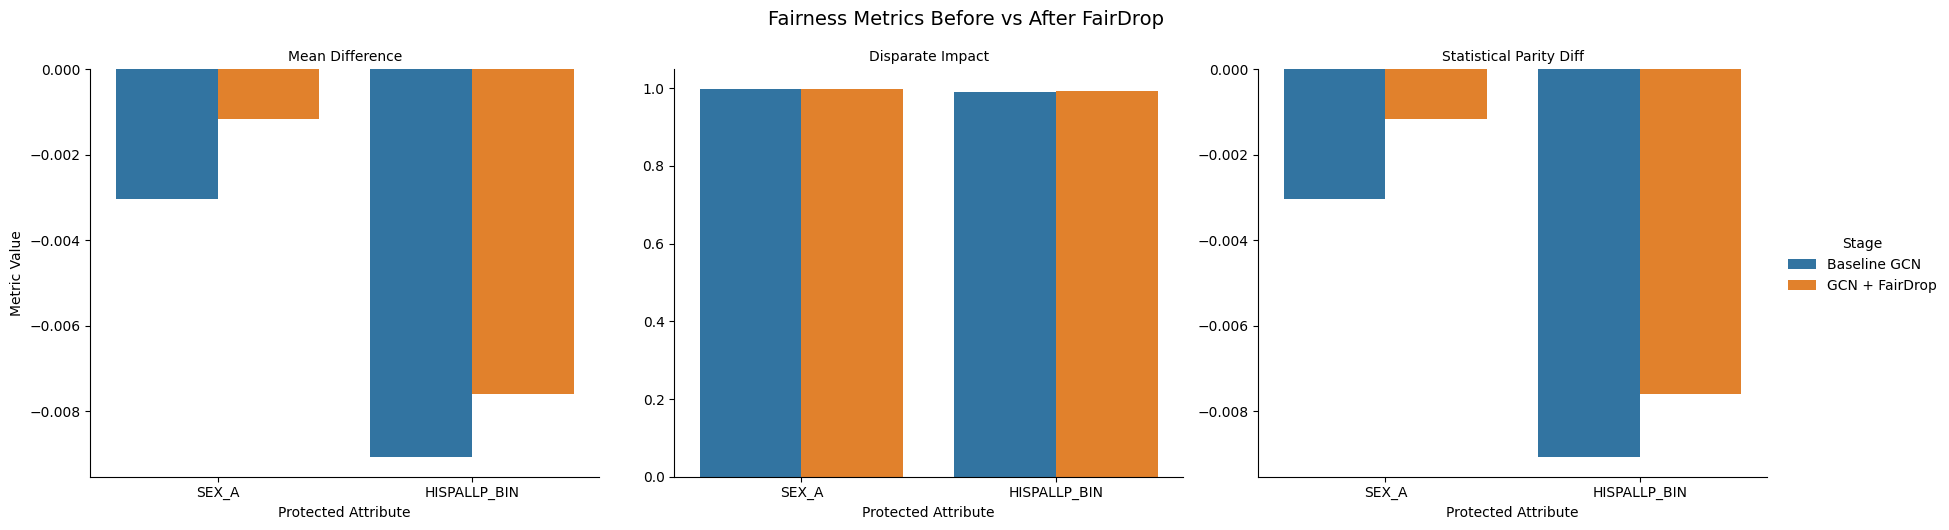

In [17]:
# Visualization Fairness Metrics Comparison

import seaborn as sns
import matplotlib.pyplot as plt

def plot_fairness_comparison(fairness_base, fairness_fair):
    # Add a column indicating the stage
    fairness_base = fairness_base.copy()
    fairness_base["Stage"] = "Baseline GCN"

    fairness_fair = fairness_fair.copy()
    fairness_fair["Stage"] = "GCN + FairDrop"

    # Combine into one DataFrame
    df_all = pd.concat([fairness_base, fairness_fair])

    # Melt for plotting
    df_melt = df_all.melt(
        id_vars=["Protected Attribute", "Stage"],
        value_vars=["Mean Difference", "Disparate Impact", "Statistical Parity Diff"],
        var_name="Metric",
        value_name="Value"
    )

    # Plot
    g = sns.catplot(
        data=df_melt, kind="bar",
        x="Protected Attribute", y="Value",
        hue="Stage", col="Metric",
        sharey=False, height=5, aspect=1.2
    )
    g.set_axis_labels("Protected Attribute", "Metric Value")
    g.set_titles("{col_name}")
    plt.suptitle("Fairness Metrics Before vs After FairDrop", y=1.05, fontsize=14)
    plt.show()

    

plot_fairness_comparison(fairness_base, fairness_fair)


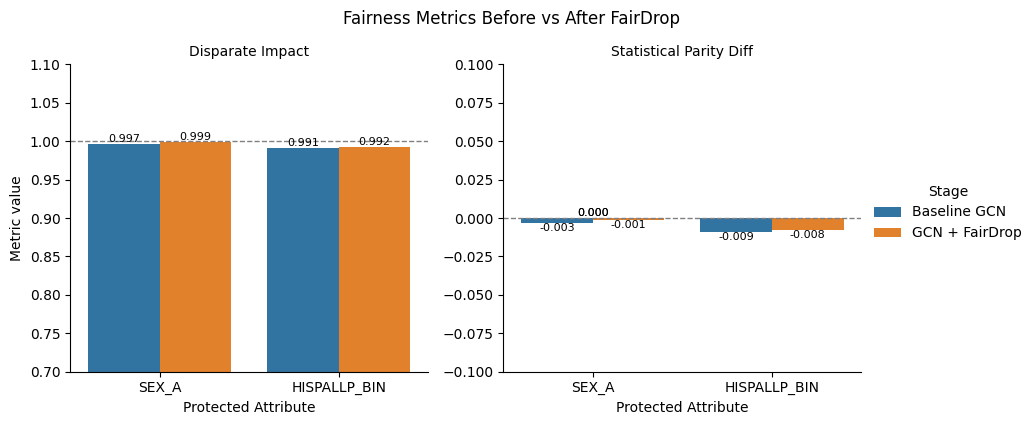

In [20]:
# Visualization Fairness Metrics Comparison (Only SPD & DI)
import seaborn as sns
import matplotlib.pyplot as plt

def plot_fairness_comparison_clean(fairness_base, fairness_fair, show_metric_values=True):
    base = fairness_base.copy(); base["Stage"] = "Baseline GCN"
    fair = fairness_fair.copy(); fair["Stage"] = "GCN + FairDrop"
    df_all = pd.concat([base, fair])

    # Keep only SPD and DI to avoid the sign mirror confusion
    keep = ["Protected Attribute", "Stage", "Disparate Impact", "Statistical Parity Diff"]
    df_all = df_all[keep]

    df_melt = df_all.melt(
        id_vars=["Protected Attribute", "Stage"],
        value_vars=["Disparate Impact", "Statistical Parity Diff"],
        var_name="Metric", value_name="Value"
    )

    g = sns.catplot(
        data=df_melt, kind="bar",
        x="Protected Attribute", y="Value",
        hue="Stage", col="Metric", sharey=False,
        height=4, aspect=1.1
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Protected Attribute", "Metric value")

    # helpful y-lims
    for ax, metric in zip(g.axes.flat, ["Disparate Impact", "Statistical Parity Diff"]):
        if metric == "Disparate Impact":
            ax.set_ylim(0.7, 1.1)  # zoom around 1
            ax.axhline(1.0, ls="--", lw=1, color="gray")
        else:
            ax.set_ylim(-0.1, 0.1)  # zoom around 0
            ax.axhline(0.0, ls="--", lw=1, color="gray")

        if show_metric_values:
            for p in ax.patches:
                val = p.get_height()
                ax.annotate(f"{val:.3f}", (p.get_x()+p.get_width()/2, val),
                            ha='center', va='bottom' if val>=0 else 'top', fontsize=8, rotation=0)

    plt.suptitle("Fairness Metrics Before vs After FairDrop", y=1.05)
    plt.show()

plot_fairness_comparison_clean(fairness_base, fairness_fair)


In [4]:
#Sweep FairDrop Hyperparameter (p grid search)
from IPython.display import display
import numpy as np
import pandas as pd
import torch
from torch_geometric.utils import dropout_edge
import matplotlib.pyplot as plt

# helper: random-edge FairDrop 
def fairdrop_edge_index(edge_index, drop_rate, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    ed, _ = dropout_edge(edge_index, p=drop_rate)
    return ed

# helper: summarize fairness into a single score to compare p values 
def summarize_fairness(fair_df):
    # Want SPD close to 0 and DI close to 1, across attributes.
    spd = fair_df["Statistical Parity Diff"].abs().max()
    di_dev = (fair_df["Disparate Impact"] - 1.0).abs().max()
    
    score = max(spd, di_dev)
    return {"max_abs_SPD": float(spd), "max_abs_DI_dev": float(di_dev), "fairness_score": float(score)}


def sweep_fairdrop_rates(edge_index, y, df, p_list, seeds, acc_base, acc_tolerance=0.03):
    rows = []
    for p in p_list:
        accs = []
        fairness_records = [] 
        for s in seeds:
            ed_fair = fairdrop_edge_index(edge_index, drop_rate=p, seed=s)
            model = train_model(ed_fair, epochs=200)
            pred, acc = evaluate_model(model, ed_fair)

            # fairness for both attributes
            fair_df = evaluate_fairness_multi(
                y.numpy(), pred,
                df.loc[:, ["SEX_A", "HISPALLP_BIN"]],
                prot_cols=["SEX_A", "HISPALLP_BIN"]
            )
            accs.append(acc)

            record = {"p": p, "seed": s, "acc": acc}
            for _, row in fair_df.iterrows():
                prot = row["Protected Attribute"]
                record[f"SPD_{prot}"] = row["Statistical Parity Diff"]
                record[f"DI_{prot}"] = row["Disparate Impact"]
            fairness_records.append(record)

        # average across seeds
        df_attr = pd.DataFrame(fairness_records)
        row_mean = df_attr.mean(numeric_only=True).to_dict()
        row_mean["p"] = p
        row_mean["acc_mean"] = np.mean(accs)
        row_mean["acc_std"]  = np.std(accs)
        rows.append(row_mean)

    results = pd.DataFrame(rows).sort_values("p").reset_index(drop=True)
    results["fairness_score"] = results.apply(
        lambda r: max(abs(r["SPD_SEX_A"]), abs(r["SPD_HISPALLP_BIN"]),
                      abs(r["DI_SEX_A"]-1), abs(r["DI_HISPALLP_BIN"]-1)), axis=1
    )

    feasible = results[results["acc_mean"] >= acc_base * (1 - acc_tolerance)]
    if len(feasible) == 0:
        rec = results.sort_values("fairness_score").iloc[0]
        print("⚠️ No p met accuracy tolerance; picking fairest overall.")
    else:
        rec = feasible.sort_values("fairness_score").iloc[0]

    print("\n=== Detailed FairDrop sweep ===")
    display(results)
    print(f"\nRecommended p = {rec['p']:.2f}  "
          f"(acc={rec['acc_mean']:.3f}, fairness_score={rec['fairness_score']:.4f})")

    return results, rec





In [2]:
#Importing k-NN graph for reweighed dataset
import pickle
import numpy as np
import torch

# Load precomputed graph
with open("knn_graph.pkl", "rb") as f:
    G_final = pickle.load(f)

# Convert to edge_index
edges = np.array(G_final.edges())
edge_index = torch.tensor(edges.T, dtype=torch.long)

print(edge_index.shape)   # [2, num_edges]


torch.Size([2, 60])


In [3]:
#Building Pythorch Data for new dataset
import pandas as pd
from torch_geometric.data import Data

# Load dataset again
df = pd.read_csv("reweighed_intersectional.csv")

# Extract features
X = torch.tensor(df[["SEX_A", "HISPALLP_BIN", "ANXEV_A"]].values, dtype=torch.float)

# Build Data object
data = Data(x=X, edge_index=edge_index)

print(data)
# Example: Data(x=[N, 3], edge_index=[2, E])


Data(x=[29460, 3], edge_index=[2, 60])


In [4]:
#Using the same predefined GCN with new dataset
model = GCN(input_dim=3, hidden_dim=16, output_dim=8)
out = model(data.x, data.edge_index)
print("Embeddings shape:", out.shape)



NameError: name 'GCN' is not defined